# Delivery delays and customer reviews

Notebook 01 measured how long delivery takes and how accurate Olist's promise is. This one
looks at what happens when the promise breaks. How review scores change when an order
arrives late, and where those late orders come from.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('default')
plt.rcParams.update({
    'figure.facecolor': 'white',
    'savefig.facecolor': 'white',
    'savefig.dpi': 150,
    'savefig.bbox': 'tight',
    'axes.grid': True,
    'grid.alpha': 0.3,
})

In [2]:
clean = pd.read_parquet("../data/clean/clean.parquet")
reviews = pd.read_csv("../data/raw/olist_order_reviews_dataset.csv")

print("clean: ", clean.shape)
print("reviews: ", reviews.shape)

clean:  (96470, 37)
reviews:  (99224, 7)


In [3]:
reviews.head(2)

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13


In [4]:
reviews['review_score'].value_counts()

review_score
5    57328
4    19142
1    11424
3     8179
2     3151
Name: count, dtype: int64

In [5]:
print("Unique: ", reviews['order_id'].nunique())

Unique:  98673


In [6]:
main_review = (reviews
               .sort_values(['review_creation_date'], ascending=False)
               .drop_duplicates('order_id'))

In [7]:
print("Cleaned reviews",main_review.shape)

Cleaned reviews (98673, 7)


In [8]:
df = clean.merge(main_review[['order_id', 'review_score', 'review_creation_date']], on='order_id', how='inner')
print("Length before merge: ", len(clean))
print("Length after merge: ", len(df))

Length before merge:  96470
Length after merge:  95824


646 delivered orders have no review, 0.7% of the total.

In [9]:
df['days_late'] = df['delivery_days'] - df['estimated_days']
df.head(5)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_days,purchase_month,...,customer_zip_code_prefix,customer_lat,customer_lng,seller_zip_code_prefix,seller_lat,seller_lng,distance_km,review_score,review_creation_date,days_late
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8.436574,10,...,3149,-23.576170,-46.587276,9350,-23.681180,-46.444127,18.681711,4,2017-10-11 00:00:00,-8.107488
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,13.782037,7,...,47813,-12.126651,-45.008162,31570,-19.807013,-43.980966,861.035367,4,2018-08-08 00:00:00,-6.355729
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,9.394213,8,...,75265,-16.744472,-48.514624,14840,-21.364020,-48.228831,514.547140,5,2018-08-18 00:00:00,-18.245498
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,13.208750,11,...,59296,-5.774611,-35.273916,31842,-19.836541,-43.921855,1821.802656,5,2017-12-03 00:00:00,-13.980069
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2.873877,2,...,9195,-23.675316,-46.515116,8752,-23.545033,-46.261847,29.593095,5,2018-02-17 00:00:00,-10.238171


days_late is the gap between actual and promised delivery. Positive means the order
arrived after the promised date, negative means it came early.

In [10]:
print(df.groupby('is_late')['review_score'].agg(['mean', 'count']).round(2))

         mean  count
is_late             
0        4.29  89443
1        2.27   6381


Late orders average 2.27 against 4.29 for on-time ones. A broken promise costs roughly
two stars. Only 6,381 orders out of 95,824 arrive late, but each one lands near the
bottom of the scale.

In [11]:
df['late_bin'] = pd.cut(df['days_late'], bins=[-200, -14, -7, -3, 0, 3, 7, 14, 200])

In [12]:
print(df.groupby('late_bin', observed=True)['review_score'].agg(['mean', 'count']).round(2))

             mean  count
late_bin                
(-200, -14]  4.32  41861
(-14, -7]    4.30  33883
(-7, -3]     4.19   9429
(-3, 0]      4.11   4270
(0, 3]       3.29   1852
(3, 7]       2.10   1748
(7, 14]      1.67   1446
(14, 200]    1.72   1335


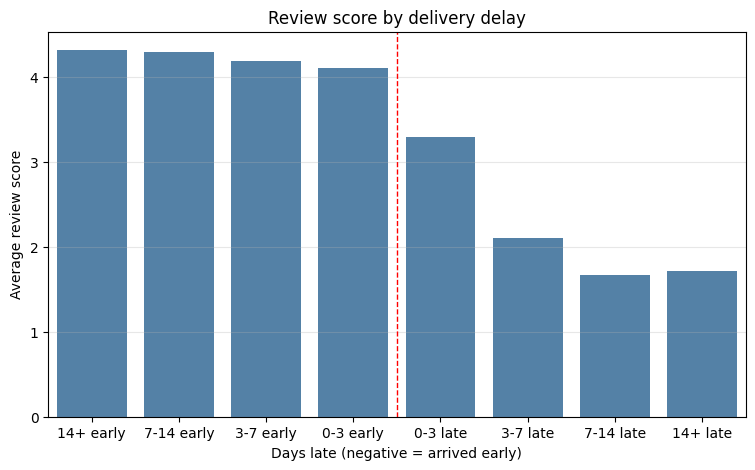

In [15]:
by_bin = (df
          .groupby('late_bin', observed=True)['review_score']
          .agg(['mean', 'count'])
          .round(2)
          .reset_index())


plt.figure(figsize=(9, 5))
sns.barplot(data=by_bin, x='late_bin', y='mean', color='steelblue')
plt.axvline(3.5, color='red', linestyle='--', linewidth=1)
plt.title('Review score by delivery delay')
plt.xlabel('Days late (negative = arrived early)')
plt.ylabel('Average review score')
labels = ['14+ early', '7-14 early', '3-7 early', '0-3 early',
          '0-3 late', '3-7 late', '7-14 late', '14+ late']
plt.xticks(range(8), labels)
plt.savefig('../images/score_by_delay.png')
plt.show()

Arriving early buys nothing. Scores hold at 4.1 to 4.3 whether the order came one day
ahead or two weeks ahead.

Crossing the promised date is what hurts. One to three days late drops the score from
4.11 to 3.29. Beyond a week it bottoms out near 1.7 and stops falling.

The penalty is one-sided, which is why Olist pads the promise with a 12-day buffer
instead of tightening it.